
# Обучение модели YOLOv8 для Raspberry Pi

## Установка зависимостей

In [2]:
# Выполни один раз (если ещё не установлено):
# pip install ultralytics opencv-python pyyaml matplotlib

import sys, platform
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())

Python: 3.12.10
Platform: macOS-15.7.1-arm64-arm-64bit


## Импорт библиотек

In [3]:
from ultralytics import YOLO
import cv2
import yaml
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [22]:
import ultralytics
import torch

print("numpy", np.__version__)
print("ultralytics", ultralytics.__version__)
print("torch", torch.__version__)
print("platform", platform.platform())

numpy 2.4.1
ultralytics 8.4.9
torch 2.10.0
platform macOS-15.7.1-arm64-arm-64bit


## Экспорт датасета из Roboflow

- Создайте папку `dataset/`
- Распакуйте Roboflow zip **внутрь** `dataset/`

## Путь к датасету

In [4]:

# Укажите путь к папке, где лежит data.yaml
DATA_ROOT = Path("./dataset").resolve()

data_yaml_path = DATA_ROOT / "data.yaml"
print("DATA_ROOT =", DATA_ROOT)
print("data.yaml =", data_yaml_path)

assert DATA_ROOT.exists(), f"DATA_ROOT не найден: {DATA_ROOT}"
assert data_yaml_path.exists(), f"Не найден data.yaml: {data_yaml_path}"


DATA_ROOT = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/dataset
data.yaml = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/dataset/data.yaml


## Чтение data.yaml и формирование путей к train/valid/test

In [5]:
import yaml
from pathlib import Path

data = yaml.safe_load(data_yaml_path.read_text(encoding="utf-8"))

# valid → val
if "val" not in data and "valid" in data:
    data["val"] = data["valid"]

# classes
names = data["names"]
CLASS_NAMES = [names[i] for i in sorted(names)] if isinstance(names, dict) else names

yaml_dir = data_yaml_path.parent.resolve()   # .../dataset

def resolve_images_dir(v: str) -> Path:
    p = Path(v)
    if p.is_absolute():
        return p
    # сначала как написано (../...)
    p1 = (yaml_dir / p).resolve()
    if p1.exists():
        return p1
    # fallback: внутри dataset/
    while p.parts and p.parts[0] == "..":
        p = Path(*p.parts[1:])
    return (yaml_dir / p).resolve()

train_images_dir = resolve_images_dir(data["train"])
val_images_dir   = resolve_images_dir(data["val"])
test_images_dir  = resolve_images_dir(data["test"]) if "test" in data else None

train_labels_dir = train_images_dir.parent / "labels"
val_labels_dir   = val_images_dir.parent / "labels"
test_labels_dir  = test_images_dir.parent / "labels" if test_images_dir else None

for p in (train_images_dir, train_labels_dir, val_images_dir, val_labels_dir):
    assert p.exists(), f"Не найдена папка: {p}"

print("Train:", train_images_dir)
print("Val:  ", val_images_dir)
if test_images_dir:
    print("Test: ", test_images_dir)


Train: /Users/aleksioprime/edu/gymnasium/sk_aisb/training/dataset/train/images
Val:   /Users/aleksioprime/edu/gymnasium/sk_aisb/training/dataset/valid/images
Test:  /Users/aleksioprime/edu/gymnasium/sk_aisb/training/dataset/test/images


## Демонстрация изображений из обучающего набора

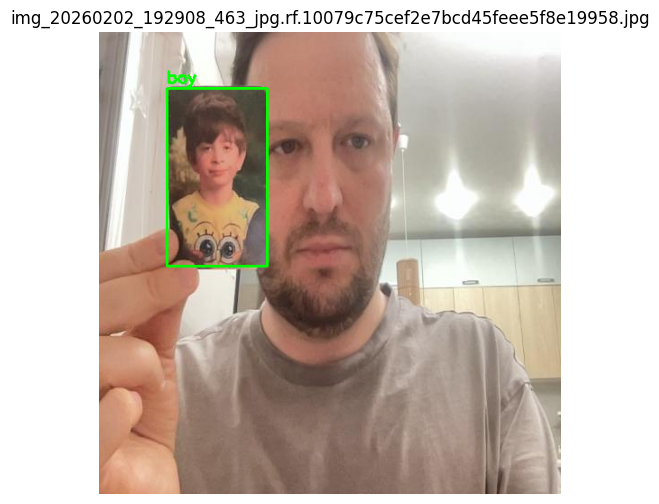

In [6]:
def read_yolo_labels(label_path: Path):
    boxes = []
    if not label_path.exists():
        return boxes
    txt = label_path.read_text(encoding="utf-8").strip()
    if not txt:
        return boxes
    for line in txt.splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls, xc, yc, w, h = parts
        boxes.append((int(cls), float(xc), float(yc), float(w), float(h)))
    return boxes

def draw_boxes(img_bgr, boxes, class_names):
    h, w = img_bgr.shape[:2]
    out = img_bgr.copy()
    for cls, xc, yc, bw, bh in boxes:
        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w-1, x2), min(h-1, y2)
        cv2.rectangle(out, (x1, y1), (x2, y2), (0,255,0), 2)
        name = class_names[cls] if 0 <= cls < len(class_names) else str(cls)
        cv2.putText(out, name, (x1, max(0, y1-6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
    return out

imgs = sorted(list(train_images_dir.glob("*.*")))
assert len(imgs) > 0, f"Нет изображений в {train_images_dir}"

for img_path in random.sample(imgs, k=min(1, len(imgs))):
    label_path = train_labels_dir / (img_path.stem + ".txt")
    img = cv2.imread(str(img_path))
    assert img is not None, f"Не удалось прочитать: {img_path}"
    boxes = read_yolo_labels(label_path)
    vis = draw_boxes(img, boxes, CLASS_NAMES)
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(9, 6))
    plt.title(img_path.name)
    plt.axis("off")
    plt.imshow(vis_rgb)
    plt.show()

## Обучение YOLOv8n

In [9]:

MODEL_NAME = "yolov8n.pt"
EPOCHS = 80
IMGSZ_TRAIN = 320
BATCH = 16

DEVICE = "mps"

WORKERS = 0 if DEVICE == "mps" else 2

# Попробуем автоматически выбрать MPS на macOS (Apple Silicon), если доступно
try:
    import torch
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        DEVICE = "mps"
except Exception:
    pass

print("Using DEVICE =", DEVICE)

model = YOLO(MODEL_NAME)
train_results = model.train(
    data=str(data_yaml_path),
    epochs=EPOCHS,
    imgsz=IMGSZ_TRAIN,
    batch=BATCH,
    device=DEVICE,
    workers=WORKERS,
    project="runs_train",
    name="exp_pc_roboflow",
    patience=20,
    close_mosaic=10,
)
print("Train done")

Using DEVICE = mps


KeyboardInterrupt: 

## Валидация и лучшая модель

In [10]:

best_pt = Path("runs/detect/runs_train/exp_pc_roboflow/weights/best.pt")
last_pt = Path("runs/detect/runs_train/exp_pc_roboflow/weights/last.pt")

print("best:", best_pt, "exists:", best_pt.exists())
print("last:", last_pt, "exists:", last_pt.exists())
assert best_pt.exists(), "Не найден best.pt — проверь, что обучение завершилось."

trained = YOLO(str(best_pt))

metrics = trained.val(
    data=str(data_yaml_path),
    imgsz=IMGSZ_TRAIN,
    device=DEVICE,
)
print(metrics)


best: runs/detect/runs_train/exp_pc_roboflow/weights/best.pt exists: True
last: runs/detect/runs_train/exp_pc_roboflow/weights/last.pt exists: True
Ultralytics 8.4.9 🚀 Python-3.12.10 torch-2.10.0 MPS (Apple M1)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.1 ms, read: 103.7±70.0 MB/s, size: 27.4 KB)
val: Scanning /Users/aleksioprime/edu/gymnasium/sk_aisb/training/dataset/valid/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 455.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.2s/it 1.2s
                   all          5          5      0.975          1      0.995      0.937
                   boy          2          2      0.982          1      0.995       0.92
                   cat          1          1      0.967          1      0.995      0.995
                   fox          2          2      0.976          1

## Предварительная оценка качества модели на валидационной выборке

In [14]:
_ = trained.predict(
    source=str(val_images_dir),
    imgsz=320,
    conf=0.35,
    device=DEVICE,
    save=True,
    project="runs_predict",
    name="val_pred",
    verbose=False
)
print("Saved predictions to runs_predict/val_pred")

Results saved to /Users/aleksioprime/edu/gymnasium/sk_aisb/training/runs/detect/runs_predict/val_pred
Saved predictions to runs_predict/val_pred


## Предварительная оценка качества модели на тестовой выборке

In [15]:
_ = trained.predict(
    source=str(test_images_dir),
    imgsz=320,
    conf=0.35,
    save=True,
    project="runs_predict",
    name="test_pred",
)

print("Saved predictions to runs_predict/test_pred")

Results saved to /Users/aleksioprime/edu/gymnasium/sk_aisb/training/runs/detect/runs_predict/test_pred
Saved predictions to runs_predict/test_pred


In [17]:
import shutil
import time

ART_DIR = Path("artifacts").resolve()
ART_DIR.mkdir(parents=True, exist_ok=True)

timestamp = time.strftime("%Y%m%d-%H%M%S")
FINAL_DIR = ART_DIR / f"yolo_export_{timestamp}"
FINAL_DIR.mkdir(parents=True, exist_ok=True)

best_pt = Path(best_pt).resolve()
assert best_pt.exists(), f"best.pt не найден: {best_pt}"

final_best_pt = FINAL_DIR / "best.pt"
shutil.copy2(best_pt, final_best_pt)

print("Saved:", final_best_pt)
print("FINAL_DIR:", FINAL_DIR)

Saved: /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best.pt
FINAL_DIR: /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210


In [18]:
from ultralytics import YOLO
from pathlib import Path

trained = YOLO(str(final_best_pt))  # загружаем из artifacts, чтобы точно всё было локально

EXPORTS = [
    ("zero2w", 256),
    ("pi4",    320),
]

export_paths = []

for tag, sz in EXPORTS:
    out_dir = FINAL_DIR / f"export_{tag}_{sz}"
    out_dir.mkdir(exist_ok=True)

    # NCNN
    print(f"[{tag}] Export NCNN imgsz={sz} ...")
    ncnn_path = trained.export(format="ncnn", imgsz=sz)
    # Ultralytics вернёт путь к артефакту (строка). Переместим в нашу папку.
    if ncnn_path:
        ncnn_path = Path(str(ncnn_path)).resolve()
        if ncnn_path.exists():
            shutil.move(str(ncnn_path), str(out_dir / ncnn_path.name))
            export_paths.append(out_dir / ncnn_path.name)

    # TFLite
    print(f"[{tag}] Export TFLite imgsz={sz} ...")
    tflite_path = trained.export(format="tflite", imgsz=sz)
    if tflite_path:
        tflite_path = Path(str(tflite_path)).resolve()
        if tflite_path.exists():
            shutil.move(str(tflite_path), str(out_dir / tflite_path.name))
            export_paths.append(out_dir / tflite_path.name)

    print(f"[{tag}] Saved exports to:", out_dir)

print("Done. FINAL_DIR =", FINAL_DIR)

[zero2w] Export NCNN imgsz=256 ...
Ultralytics 8.4.9 🚀 Python-3.12.10 torch-2.10.0 CPU (Apple M1)
WARNING ⚠️ NCNN export does not support end2end models, disabling end2end branch.
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best.pt' with input shape (1, 3, 256, 256) BCHW and output shape(s) (1, 7, 1344) (17.6 MB)

NCNN: starting export with NCNN 1.0.20260114 and PNNX 20260112...


pnnxparam = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model/model.pnnx.param
pnnxbin = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model/model.pnnx.bin
pnnxpy = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model/model_pnnx.py
pnnxonnx = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model/model.pnnx.onnx
ncnnparam = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model/model.ncnn.param
ncnnbin = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model/model.ncnn.bin
ncnnpy = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model/model_ncnn.py
fp16 = 0
optlevel = 2
device = cpu
inputshape = [1,3,256,256]f32
inputshape2 = 
cust

NCNN: export success ✅ 2.7s, saved as '/Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model' (11.5 MB)

Export complete (2.8s)
Results saved to /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210
Predict:         yolo predict task=detect model=/Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model imgsz=256 
Validate:        yolo val task=detect model=/Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model imgsz=256 data=/Users/aleksioprime/edu/gymnasium/sk_aisb/training/dataset/data.yaml  
Visualize:       https://netron.app
[zero2w] Export TFLite imgsz=256 ...
Ultralytics 8.4.9 🚀 Python-3.12.10 torch-2.10.0 CPU (Apple M1)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20

/Users/aleksioprime/.pyenv/versions/demo/lib/python3.12/site-packages/torch/onnx/_internal/torchscript_exporter/utils.py:552: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  _export(


ONNX: slimming with onnxslim 0.1.82...
ONNX: export success ✅ 4.0s, saved as '/Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best.onnx' (11.6 MB)
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /Users/aleksioprime/edu/gymnasium/sk_aisb/training/calibration_image_sample_data_20x128x128x3_float32.npy...: 100% ━━━━━━━━━━━━ 1/1 58.7files/s 0.0s
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at '/Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 256, 256, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 7, 1344), dtype=tf.float32, name=None)
Captures:
  14007015504: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  14007015312: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)


...

pnnxparam = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model/model.pnnx.param
pnnxbin = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model/model.pnnx.bin
pnnxpy = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model/model_pnnx.py
pnnxonnx = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model/model.pnnx.onnx
ncnnparam = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model/model.ncnn.param
ncnnbin = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model/model.ncnn.bin
ncnnpy = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model/model_ncnn.py
fp16 = 0
optlevel = 2
device = cpu
inputshape = [1,3,320,320]f32
inputshape2 = 
cust

NCNN: export success ✅ 2.6s, saved as '/Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model' (11.6 MB)

Export complete (2.7s)
Results saved to /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210
Predict:         yolo predict task=detect model=/Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model imgsz=320 
Validate:        yolo val task=detect model=/Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_ncnn_model imgsz=320 data=/Users/aleksioprime/edu/gymnasium/sk_aisb/training/dataset/data.yaml  
Visualize:       https://netron.app
[pi4] Export TFLite imgsz=320 ...
Ultralytics 8.4.9 🚀 Python-3.12.10 torch-2.10.0 CPU (Apple M1)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260

I0000 00:00:1770057390.110210   15493 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1770057390.110337   15493 single_machine.cc:374] Starting new session
W0000 00:00:1770057390.478116   15493 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770057390.478129   15493 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1770057390.824793   15493 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1770057390.824878   15493 single_machine.cc:374] Starting new session


TensorFlow SavedModel: export success ✅ 5.1s, saved as '/Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_saved_model' (29.1 MB)

TensorFlow Lite: starting export with tensorflow 2.19.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_saved_model/best_float32.tflite' (11.6 MB)

Export complete (5.3s)
Results saved to /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210
Predict:         yolo predict task=detect model=/Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_saved_model/best_float32.tflite imgsz=320 
Validate:        yolo val task=detect model=/Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export_20260202-213210/best_saved_model/best_float32.tflite imgsz=320 data=/Users/aleksioprime/edu/gymnasium/sk_aisb/training/dataset/data.yaml  
Visualize

W0000 00:00:1770057391.471085   15493 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770057391.471099   15493 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


In [ ]:
import shutil

zip_path = shutil.make_archive(str(FINAL_DIR), "zip", root_dir=str(FINAL_DIR))
print("Created ZIP:", zip_path)

In [ ]:
import shutil
from pathlib import Path

TO_DELETE = [
    Path("runs"),          # Ultralytics default
    Path("runs_train"),    # если ты использовал такое
    Path("runs_predict"),  # если ты сохранял предикты туда
    Path("__pycache__"),
]

for p in TO_DELETE:
    p = p.resolve()
    if p.exists() and p.is_dir():
        # никогда не удаляем artifacts
        if p.name == "artifacts":
            continue
        shutil.rmtree(p)
        print("Deleted:", p)
    else:
        print("Skip:", p)

print("Cleanup done. Kept:", ART_DIR)
